# PSY 39200 Introduction to Computational Psychology and AI

## Week 07 Introduction to Artificial Neural Networks  

## There are 3 sets of questions and 4 coding exercises in this tutorial

## Zhixian Han <br> Department of Psychological Sciences <br> Purdue University

### Part of this tutorial is adapted from Neuromatch Academy Tutorials (CC-BY licensed) https://neuromatch.io/open-education-resources/






# This a GPU-Free tutorial

In [1]:
# @title Set Up Code

import torch
import numpy as np
from torch import nn
from math import pi
import matplotlib.pyplot as plt


# Figure settings
import logging
logging.getLogger('matplotlib.font_manager').disabled = True

import ipywidgets as widgets  # Interactive display
%config InlineBackend.figure_format = 'retina'
plt.style.use("https://raw.githubusercontent.com/NeuromatchAcademy/content-creation/main/nma.mplstyle")



# Plotting functions

from mpl_toolkits.axes_grid1 import make_axes_locatable

def ex3_plot(model, x, y, ep, lss):
  """
  Plot training loss

  Args:
    model: nn.module
      Model implementing regression
    x: np.ndarray
      Training Data
    y: np.ndarray
      Targets
    ep: int
      Number of epochs
    lss: function
      Loss function

  Returns:
    Nothing
  """
  f, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
  ax1.set_title("Regression")
  ax1.plot(x, model(x).detach().numpy(), color='r', label='prediction')
  ax1.scatter(x, y, c='c', label='targets')
  ax1.set_xlabel('x')
  ax1.set_ylabel('y')
  ax1.legend()

  ax2.set_title("Training loss")
  ax2.plot(np.linspace(1, epochs, epochs), losses, color='y')
  ax2.set_xlabel("Epoch")
  ax2.set_ylabel("MSE")

  plt.show()


def ex1_plot(fun_z, fun_dz):
  """
  Plots the function and gradient vectors

  Args:
    fun_z: f.__name__
      Function implementing sine function
    fun_dz: f.__name__
      Function implementing sine function as gradient vector

  Returns:
    Nothing
  """
  x, y = np.arange(-3, 3.01, 0.02), np.arange(-3, 3.01, 0.02)
  xx, yy = np.meshgrid(x, y, sparse=True)
  zz = fun_z(xx, yy)
  xg, yg = np.arange(-2.5, 2.6, 0.5), np.arange(-2.5, 2.6, 0.5)
  xxg, yyg = np.meshgrid(xg, yg, sparse=True)
  zxg, zyg = fun_dz(xxg, yyg)

  plt.figure(figsize=(8, 7))
  plt.title("Gradient vectors point towards steepest ascent")
  contplt = plt.contourf(x, y, zz, levels=20)
  plt.quiver(xxg, yyg, zxg, zyg, scale=50, color='r', )
  plt.xlabel('$x$')
  plt.ylabel('$y$')
  ax = plt.gca()
  divider = make_axes_locatable(ax)
  cax = divider.append_axes("right", size="5%", pad=0.05)
  cbar = plt.colorbar(contplt, cax=cax)
  cbar.set_label('$z = h(x, y)$')

  plt.show()




# Set random seed

# Executing `set_seed(seed=seed)` you are setting the seed

# For DL its critical to set the random seed so that students can have a
# baseline to compare their results to expected results.
# Read more here: https://pytorch.org/docs/stable/notes/randomness.html

# Call `set_seed` function in the exercises to ensure reproducibility.
import random
import torch

def set_seed(seed=None, seed_torch=True):
  """
  Function that controls randomness. NumPy and random modules must be imported.

  Args:
    seed : Integer
      A non-negative integer that defines the random state. Default is `None`.
    seed_torch : Boolean
      If `True` sets the random seed for pytorch tensors, so pytorch module
      must be imported. Default is `True`.

  Returns:
    Nothing.
  """
  if seed is None:
    seed = np.random.choice(2 ** 32)
  random.seed(seed)
  np.random.seed(seed)
  if seed_torch:
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

  print(f'Random seed {seed} has been set.')


# In case that `DataLoader` is used
def seed_worker(worker_id):
  """
  DataLoader will reseed workers following randomness in
  multi-process data loading algorithm.

  Args:
    worker_id: integer
      ID of subprocess to seed. 0 means that
      the data will be loaded in the main process
      Refer: https://pytorch.org/docs/stable/data.html#data-loading-randomness for more details

  Returns:
    Nothing
  """
  worker_seed = torch.initial_seed() % 2**32
  np.random.seed(worker_seed)
  random.seed(worker_seed)






# Import dependencies

# Standard library imports
import logging
from datetime import datetime
import pdb  # we encourage you to use the debugger, rather than print statements!
import time

# Third-party imports
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
from tqdm import tqdm
from IPython.display import display, HTML

In [2]:
# @title Helper functions

# The sigmoid activation function
def sigmoid(X):
    """
    Returns the sigmoid function, i.e. 1/(1+exp(-X))
    """

    # to avoid runtime warnings, if abs(X) is more than 500, we just cap it there
    Y = X.copy()  # this ensures we don't overwrite entries in X - Python can be a trickster!
    toobig = X > 500
    toosmall = X < -500
    Y[toobig] = 500
    Y[toosmall] = -500

    return 1.0 / (1.0 + np.exp(-Y))

# The ReLU activation function
def ReLU(X):
    """
    Returns the ReLU function, i.e. X if X > 0, 0 otherwise
    """

    # to avoid runtime warnings, if abs(X) is more than 500, we just cap it there
    Y = X.copy()  # this ensures we don't overwrite entries in X - Python can be a trickster!
    neg = X < 0
    Y[neg] = 0

    return Y


# A helper function to add an "always on" unit to the inputs, let's us keep the biases in the weight matrices
def add_bias(inputs):
    """
    Append an "always on" bias unit to some inputs
    """
    return np.append(inputs, np.ones((1, inputs.shape[1])), axis=0)


# Creates a random set of batches, returns an array of indices, one for each batch
def create_batches(rng, batch_size, num_samples):
    """
    For a given number of samples, returns an array of indices of random batches of the specified size.

    If the size of the data is not divisible by the batch size some samples will not be included.
    """

    # determine the total number of batches
    num_batches = int(np.floor(num_samples / batch_size))

    # get the batches (without replacement)
    return rng.choice(np.arange(num_samples), size=(num_batches, batch_size), replace=False)


# Calculate the accuracy of the network on some data
def calculate_accuracy(outputs, targets):
    """
    Calculate the accuracy in categorization of some outputs given some targets.
    """

    # binarize the outputs for an easy calculation
    categories = (outputs == np.tile(outputs.max(axis=0), (10, 1))).astype('float')

    # get the accuracy
    accuracy = np.sum(categories * targets) / targets.shape[1]

    return accuracy * 100.0


def calculate_cosine_similarity(grad_1, grad_2):
    """
    Calculate the cosine similarity between two gradients
    """
    grad_1 = grad_1.flatten()
    grad_2 = grad_2.flatten()
    return np.dot(grad_1, grad_2) / np.sqrt(np.dot(grad_1, grad_1)) / np.sqrt(np.dot(grad_2, grad_2))


def calculate_grad_snr(grad, epsilon=1e-3):
    """
    Calculate the average SNR |mean|/std across all parameters in a gradient update
    """
    return np.mean(np.abs(np.mean(grad, axis=0)) / (np.std(grad, axis=0) + epsilon))

# The main network class
# This will function as the parent class for our networks, which will implement different learning algorithms
class MLP(object):
    """
    The class for creating and training a two-layer perceptron.
    """

    # The initialization function
    def __init__(self, rng, N=100, sigma=1.0, activation='sigmoid'):
        """
        The initialization function for the MLP.

         - N is the number of hidden units
         - sigma is the SD for initializing the weights
         - activation is the function to use for unit activity, options are 'sigmoid' and 'ReLU'
        """

        # store the variables for easy access
        self.N = N
        self.sigma = sigma
        self.activation = activation

        # initialize the weights
        self.W_h = rng.normal(scale=self.sigma, size=(self.N, 784 + 1))  # input-to-hidden weights & bias
        self.W_y = rng.normal(scale=self.sigma, size=(10, self.N + 1))  # hidden-to-output weights & bias
        self.B = rng.normal(scale=self.sigma, size=(self.N, 10))  # feedback weights

    # The non-linear activation function
    def activate(self, inputs):
        """
        Pass some inputs through the activation function.
        """
        if self.activation == 'sigmoid':
            Y = sigmoid(inputs)
        elif self.activation == 'ReLU':
            Y = ReLU(inputs)
        else:
            raise Exception("Unknown activation function")
        return Y

    # The function for performing a forward pass up through the network during inference
    def inference(self, rng, inputs, W_h=None, W_y=None, noise=0.):
        """
        Recognize inputs, i.e. do a forward pass up through the network. If desired, alternative weights
        can be provided
        """

        # load the current network weights if no weights given
        if W_h is None:
            W_h = self.W_h
        if W_y is None:
            W_y = self.W_y

        # calculate the hidden activities
        hidden = self.activate(np.dot(W_h, add_bias(inputs)))
        if not (noise == 0.):
            hidden += rng.normal(scale=noise, size=hidden.shape)

        # calculate the output activities
        output = self.activate(np.dot(W_y, add_bias(hidden)))

        if not (noise == 0.):
            output += rng.normal(scale=noise, size=output.shape)

        return hidden, output

    # A function for calculating the derivative of the activation function
    def act_deriv(self, activity):
        """
        Calculate the derivative of some activations with respect to the inputs
        """
        if self.activation == 'sigmoid':
            derivative = activity * (1 - activity)
        elif self.activation == 'ReLU':
            derivative = 1.0 * (activity > 1)
        else:
            raise Exception("Unknown activation function")
        return derivative

    def mse_loss_batch(self, rng, inputs, targets, W_h=None, W_y=None, output=None):
        """
        Calculate the mean-squared error loss on the given targets (average over the batch)
        """

        # do a forward sweep through the network
        if (output is None):
            (hidden, output) = self.inference(rng, inputs, W_h, W_y)
        return np.sum((targets - output) ** 2, axis=0)

    # The function for calculating the mean-squared error loss
    def mse_loss(self, rng, inputs, targets, W_h=None, W_y=None, output=None):
        """
        Calculate the mean-squared error loss on the given targets (average over the batch)
        """
        return np.mean(self.mse_loss_batch(rng, inputs, targets, W_h=W_h, W_y=W_y, output=output))

    # function for calculating perturbation updates
    def perturb(self, rng, inputs, targets, noise=1.0):
        """
        Calculates the weight updates for perturbation learning, using noise with SD as given
        """
        raise NotImplementedError()

    def node_perturb(self, rng, inputs, targets, noise=1.0):
        """
        Calculates the weight updates for node perturbation learning, using noise with SD as given
        """
        raise NotImplementedError()

    # function for calculating gradient updates
    def gradient(self, rng, inputs, targets):
        """
        Calculates the weight updates for gradient descent learning
        """

        # do a forward pass
        hidden, output = self.inference(rng, inputs)

        # calculate the gradients
        error = targets - output
        delta_W_h = np.dot(
            np.dot(self.W_y[:, :-1].transpose(), error * self.act_deriv(output)) * self.act_deriv(hidden), \
            add_bias(inputs).transpose())
        delta_W_y = np.dot(error * self.act_deriv(output), add_bias(hidden).transpose())

        return delta_W_h, delta_W_y

    # function for calculating feedback alignment updates
    def feedback(self, rng, inputs, targets):
        """
        Calculates the weight updates for feedback alignment learning
        """
        raise NotImplementedError()

    # function for calculating Kolen-Pollack updates
    def kolepoll(self, rng, inputs, targets, eta_back=0.01):
        """
        Calculates the weight updates for Kolen-Polack learning
        """
        raise NotImplementedError()

    def return_grad(self, rng, inputs, targets, algorithm='backprop', eta=0., noise=1.0):
        # calculate the updates for the weights with the appropriate algorithm
        if algorithm == 'perturb':
            delta_W_h, delta_W_y = self.perturb(rng, inputs, targets, noise=noise)
        elif algorithm == 'node_perturb':
            delta_W_h, delta_W_y = self.node_perturb(rng, inputs, targets, noise=noise)
        elif algorithm == 'feedback':
            delta_W_h, delta_W_y = self.feedback(rng, inputs, targets)
        elif algorithm == 'kolepoll':
            delta_W_h, delta_W_y = self.kolepoll(rng, inputs, targets, eta_back=eta)
        else:
            delta_W_h, delta_W_y = self.gradient(rng, inputs, targets)

        return delta_W_h, delta_W_y

    # function for updating the network
    def update(self, rng, inputs, targets, algorithm='backprop', eta=0.01, noise=1.0):
        """
        Updates the synaptic weights (and unit biases) using the given algorithm, options are:

        - 'backprop': backpropagation-of-error (default)
        - 'perturb' : weight perturbation (use noise with SD as given)
        - 'feedback': feedback alignment
        - 'kolepoll': Kolen-Pollack
        """

        delta_W_h, delta_W_y = self.return_grad(rng, inputs, targets, algorithm=algorithm, eta=eta, noise=noise)

        # do the updates
        self.W_h += eta * delta_W_h
        self.W_y += eta * delta_W_y

    # train the network using the update functions
    def train(self, rng, images, labels, num_epochs, test_images, test_labels, learning_rate=0.01, batch_size=20, \
              algorithm='backprop', noise=1.0, report=False, report_rate=10):
        """
        Trains the network with algorithm in batches for the given number of epochs on the data provided.

        Uses batches with size as indicated by batch_size and given learning rate.

        For perturbation methods, uses SD of noise as given.

        Categorization accuracy on a test set is also calculated.

        Prints a message every report_rate epochs if requested.

        Returns an array of the losses achieved at each epoch (and accuracies if test data given).
        """

        # provide an output message
        if report:
            print("Training starting...")

        # make batches from the data
        batches = create_batches(rng, batch_size, images.shape[1])

        # create arrays to store loss and accuracy values
        losses = np.zeros((num_epochs * batches.shape[0],))
        accuracy = np.zeros((num_epochs,))
        cosine_similarity = np.zeros((num_epochs,))

        # estimate the gradient SNR on the test set
        grad = np.zeros((test_images.shape[1], *self.W_h.shape))
        for t in range(test_images.shape[1]):
            inputs = test_images[:, [t]]
            targets = test_labels[:, [t]]
            grad[t, ...], _ = self.return_grad(rng, inputs, targets, algorithm=algorithm, eta=0., noise=noise)
        snr = calculate_grad_snr(grad)
        # run the training for the given number of epochs
        update_counter = 0
        for epoch in range(num_epochs):

            # step through each batch
            for b in range(batches.shape[0]):
                # get the inputs and targets for this batch
                inputs = images[:, batches[b, :]]
                targets = labels[:, batches[b, :]]

                # calculate the current loss
                losses[update_counter] = self.mse_loss(rng, inputs, targets)

                # update the weights
                self.update(rng, inputs, targets, eta=learning_rate, algorithm=algorithm, noise=noise)
                update_counter += 1

            # calculate the current test accuracy
            (testhid, testout) = self.inference(rng, test_images)
            accuracy[epoch] = calculate_accuracy(testout, test_labels)
            grad_test, _ = self.return_grad(rng, test_images, test_labels, algorithm=algorithm, eta=0., noise=noise)
            grad_bp, _ = self.return_grad(rng, test_images, test_labels, algorithm='backprop', eta=0., noise=noise)
            cosine_similarity[epoch] = calculate_cosine_similarity(grad_test, grad_bp)

            # print an output message every 10 epochs
            if report and np.mod(epoch + 1, report_rate) == 0:
                print("...completed ", epoch + 1,
                      " epochs of training. Current loss: ", round(losses[update_counter - 1], 2), ".")

        # provide an output message
        if report:
            print("Training complete.")

        return (losses, accuracy, cosine_similarity, snr)

In [3]:

# Set device (GPU or CPU). Execute `set_device()`
# especially if torch modules used.

# inform the user if the notebook uses GPU or CPU.

def set_device():
  """
  Set the device. CUDA if available, CPU otherwise

  Args:
    None

  Returns:
    Nothing
  """
  device = "cuda" if torch.cuda.is_available() else "cpu"
  if device != "cuda":
    print("GPU is not enabled in this notebook. \n"
          "If you want to enable it, in the menu under `Runtime` -> \n"
          "`Hardware accelerator.` and select `GPU` from the dropdown menu")
  else:
    print("GPU is enabled in this notebook. \n"
          "If you want to disable it, in the menu under `Runtime` -> \n"
          "`Hardware accelerator.` and select `None` from the dropdown menu")

  return device

SEED = 2025
set_seed(seed=SEED)
DEVICE = set_device()


Random seed 2025 has been set.
GPU is not enabled in this notebook. 
If you want to enable it, in the menu under `Runtime` -> 
`Hardware accelerator.` and select `GPU` from the dropdown menu


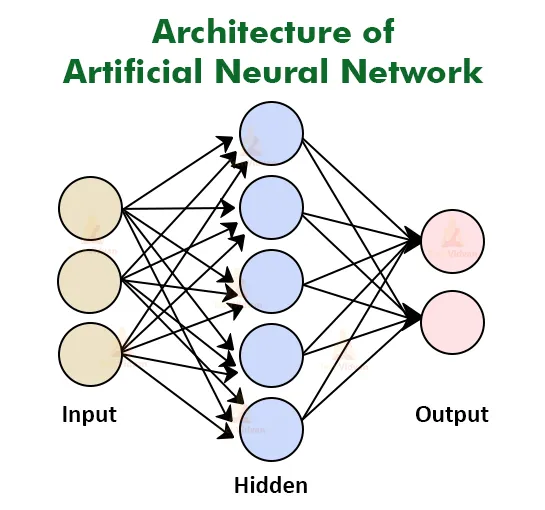

source: https://blog.knoldus.com/architecture-of-artificial-neural-network/

# Artificial Neural Networks (ANNs)

Artificial Neural Networks (ANNs) are a type of **machine learning model** inspired by the structure and function of the **brain**. They consist of interconnected units called **neurons**, which process information and learn patterns from data.

An ANN typically consists of the following layers:

**(a) Input Layer**
- The first layer that receives the **raw data**.
- Each neuron represents a **feature** of the input.

**(b) Hidden Layers**
- Intermediate layers that **process** information.
- Each neuron applies a **weighted sum** followed by an **activation function**.
- Enables the network to learn **complex patterns**.

**(c) Output Layer**
- Produces the final **predictions** or **classifications**.
- The number of neurons corresponds to the **number of output categories**.


**How ANNs Work**

Each neuron computes:

$$
h = f\left( \sum w_i x_i + b \right)
$$

where:
- $ w_i $ are the **weights** (learned during training).
- $ x_i $ are the **inputs**.
- $ b $ is the **bias** term.
- $ f(\cdot) $ is the **activation function** (e.g., ReLU, sigmoid). The network is linear if no activation function is used.


**Common Activation Functions**

| Function | Formula | Purpose |
|----------|---------|---------|
| **Sigmoid** | $ \sigma(x) = \frac{1}{1 + e^{-x}} $ | Outputs values between **0 and 1** (for probabilities). |
| **ReLU** | $ f(x) = \max\{0, x\} $ | Introduces **non-linearity**, prevents vanishing gradients. |
| **Tanh** | $ f(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}} $ | Outputs between **-1 and 1** (zero-centered). |




**Types of ANNs**

| Type | Description | Example Use Case |
|------|-------------|-----------------|
| **Hopfield Network** | Network trained using Hebbian Learning | Associative Memory Storage |
| **Multilayer Perceptron (MLP)** | Basic ANN with forward data flow only. | Simple image classification |
| **Convolutional Neural Network (CNN)** | Uses convolutional filters to detect spatial features. | Object recognition |
| **Transformer Networks** | Uses attention mechanisms for sequence modeling. | Natural language processing (GPT) |





# Supervised Learning vs Unsupervised Learning

The difference between supervised and unsupervised learning is whether **explicit labels** are provided during training.

---

## 1. Supervised Learning

Supervised learning uses labeled input-output pairs:

$$
\{(\mathbf{x}_i, y_i)\}_{i=1}^N
$$

- $\mathbf{x}_i$ = input  
- $y_i$ = correct label / target  

The goal is to learn a function:

$$
f_\theta(\mathbf{x}) \approx y
$$

by minimizing prediction error.

### Objective

Typically we minimize a loss function:

$$
\min_\theta \sum_{i=1}^N
L(f_\theta(\mathbf{x}_i), y_i)
$$

Common examples:

- **Mean Squared Error (MSE)** for regression  
- **Cross-Entropy Loss** for classification  

### Examples

- Image classification (cat vs dog)
- Predicting house prices
- Speech recognition
- Predicting neural activity from stimulus features

The model learns from **explicit teaching signals**.

You provide the correct answers (labels).

---

## 2. Unsupervised Learning

Unsupervised learning uses only inputs:

$$
\{\mathbf{x}_i\}_{i=1}^N
$$

No labels are provided.

The goal is to discover **structure** in the data.

### Typical Objectives

- Discover clusters
- Learn latent representations
- Extract principal components
- Estimate probability distributions

### Example: Principle Component Analysis (PCA)

PCA extracts the direction of maximum variance. No labels are required.

---

## Summary

Supervised learning:
- Learns from labeled data.
- Goal: predict outputs.

Unsupervised learning:
- Learns from unlabeled data.
- Goal: uncover the structure underlying data.


# Hebbian Learning for Unsupervised Learning



Hebbian Learning is a neurobiological learning principle that describes how synaptic weights in a neural network are adjusted based on the activity of neurons. It is often summarized by the phrase:

"Neurons that fire together, wire together."

### **Mathematical Formulation**
Given:
- An input vector $ \mathbf{x} \in \mathbb{R}^n $
- A weight vector $ \mathbf{w} \in \mathbb{R}^n $
- An output neuron activation $ y = \mathbf{w}^T \mathbf{x} = \sum_{j=1}^{m} x_j w_j$

The classic Hebbian weight update rule is:

$$
\Delta \mathbf{w} = \eta y \mathbf{x}
$$

where:
- $ \eta $ is the learning rate,
- $ y $ is the output neuron activation,
- $ \mathbf{x} $ is the input vector.

1. **Correlated Activity Strengthens Connections**  
   - If both input and output neurons are highly active together, the connection is strengthened.
   - If one neuron is active while the other is not, the connection does not change significantly.
  
2. **Limitations of Basic Hebbian Learning**  
   - It leads to unbounded weight growth.
   - Does not ensure stability or normalization.





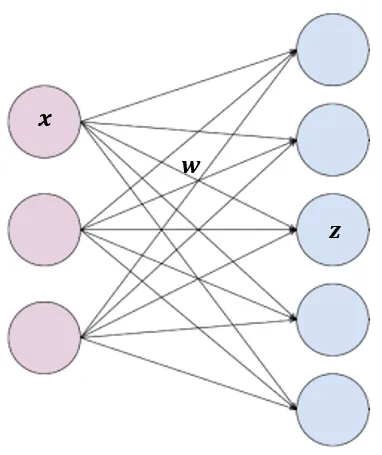

image source: https://medium.com/@reutdayan1/hebbian-learning-biologically-plausible-alternative-to-backpropagation-6ee0a24deb00

## **Oja's Rule**

Oja's Rule is a modified version of Hebbian Learning that prevents the weight vectors from growing indefinitely. It ensures that the learned weight vector remains bounded and converges to the principal component of the input data.

1. **Problem with Hebbian Learning**

 The Hebbian rule leads to **unbounded weight growth** since it continuously increases the magnitude of $ \mathbf{w} $. To prevent this, we need a normalization mechanism.

2. **Constraint: Keeping Weights Bounded**

 To stabilize learning, we impose a **weight normalization constraint**:

$$
\|\mathbf{w}\|^2 = \text{constant}
$$


 A natural way to enforce this is through **weight decay**: we introduce a term that reduces the weight magnitude when it grows too large.


3. **Modifying Hebbian Learning: Oja's Rule**

$$
\Delta \mathbf{w} = \eta y (\mathbf{x} - y\mathbf{w})
$$

where:
- $ \eta $ is the learning rate.
- $ y = \mathbf{w}^T \mathbf{x} $ is the neuron's output.
- The term $ -y\mathbf{w} $ prevents the weights from growing indefinitely.

**Properties of Oja's rule:**

1. **Normalization**:  
   - The additional term $ -y\mathbf{w} $ ensures that the weights do not diverge.
   - Without this term, the weights would grow exponentially (as in simple Hebbian learning).

2. **Principal Component Analysis (PCA) Interpretation**:  
   - Oja's rule converges to the **first principal component** of the input data distribution.
   - This makes it useful for **unsupervised learning** and **dimensionality reduction**.



### Derivation of Oja's Rule from Hebbian Learning (Optional)

Hebb's rule causes synaptic weights to grow indefinitely with a positive learning rate. To prevent this, we normalize the weight vector so that its magnitude remains constrained. We achieve this by ensuring that the weight vector remains of unit length:

$$
w_i(n+1) = \frac{w_i(n) + \eta y(\mathbf{x}) x_i}{\left(\sum_{j=1}^{m} [w_j(n) + \eta y(\mathbf{x}) x_j]^2 \right)^{1/2}}
$$


**Expansion for Small $\eta$**

For small learning rates $ |\eta| \ll 1 $, we can expand the update equation as a power series in $ \eta $ https://en.wikipedia.org/wiki/Taylor_series:

$$
w_i(n+1) = \frac{w_i(n)}{\left( \sum_j w_j^2(n) \right)^{1/2}} + \eta \left( \frac{y x_i}{\left( \sum_j w_j^2(n) \right)^{1/2}} - \frac{w_i(n) \sum_j y x_j w_j(n)}{\left( \sum_j w_j^2(n) \right)^{(1+1/2)}} \right) + O(\eta^2)
$$

For small $ \eta $, higher-order terms $ O(\eta^2) $ vanish.

For a linear neuron, the output is:

$$
y = \sum_{j=1}^{m} x_j w_j  
$$

To maintain stability, we impose the normalization condition:

$$
|\mathbf{w}| = \left( \sum_{j=1}^{m} w_j^2 \right)^{1/2} = 1
$$

Substituting the above two equations into our expansion leads to Oja's rule:

$$
w_i(n+1) = w_i(n) + \eta y(x_i - w_i(n) y)
$$

which is the same as:  

$$
\Delta \mathbf{w} = \eta y (\mathbf{x} - y\mathbf{w})
$$

This modified learning rule prevents the weights from growing indefinitely and ensures stability in synaptic weight updates.


## Hebbian Learning (Oja's rule and Sanger's rule) and Principle Component Analysis (PCA)  

### Principal Component Analysis (PCA)

Principal Component Analysis (PCA) is a dimensionality reduction technique that transforms high-dimensional data into a lower-dimensional space while preserving the most important patterns (variance) in the data.

PCA finds **principal components**, which are the directions of maximum variance in the dataset.

Given a dataset $\mathbf{X} \in \mathbb{R}^{N \times d}$, where $N$ is the number of samples and $d$ is the number of features:

1. **Compute the Mean-Centered Data**  
   Compute the mean of each feature and subtract it from the dataset:

   $$
   \mathbf{X}_{\text{centered}} = \mathbf{X} - \text{mean}(\mathbf{X})
   $$

2. **Compute the Covariance Matrix**  

   $$
   \mathbf{C} = \frac{1}{N} \mathbf{X}_{\text{centered}}^\top \mathbf{X}_{\text{centered}}
   $$

3. **Compute the Eigenvalues and Eigenvectors**  
   - Solve the eigenvalue problem:
     $$
     \mathbf{C} \mathbf{v}_i = \lambda_i \mathbf{v}_i
     $$
   - The eigenvectors ($\mathbf{v}_i$) represent the principal components.
   - The corresponding eigenvalues ($\lambda_i$) indicate the variance along each principal component.

4. **Select Top $k$ Principal Components**  
   - Sort the eigenvectors by their eigenvalues in descending order.
   - Choose the top $ k $ eigenvectors to form the transformation matrix $\mathbf{W} \in \mathbb{R}^{d \times k}$

5. **Transform the Data**  
   The data is projected onto the new lower-dimensional space:

   $$
   \mathbf{X}_{\text{reduced}} = \mathbf{X}_{\text{centered}} \mathbf{W}
   $$


**Properties of PCA**

- **Unsupervised Learning**: PCA does not require labels.

- **Variance Maximization**: The first principal component captures the maximum variance.

- **Orthogonal Transformation**: Principal components are uncorrelated.


**Applications of PCA**

- **Dimensionality Reduction**: Reduces computational complexity and removes noise.

- **Data Visualization**: Projects high-dimensional data into 2D or 3D for visualization.

- **Feature Extraction**: Identifies important patterns in large datasets.

- **Compression**: Reduces storage requirements while preserving essential information.


### Why Can Oja's Rule Be Used for PCA?

Oja's Rule is particularly useful for **Principal Component Analysis (PCA)** because it ensures that the learned weight vector converges to the **first principal component** of the input data.


### **1. PCA and Principal Components**

Principal Component Analysis (PCA) finds the **principal components** of a dataset, which are the directions along which the variance of the data is maximized. The **first principal component** corresponds to the eigenvector of the data covariance matrix with the **largest eigenvalue**.

The first principal component of PCA aims to find a weight vector $ \mathbf{w} $ such that the variance of the transformed data is maximized:

$$
\mathbf{w} = \arg\max_{\mathbf{w}} \mathbb{E}[(\mathbf{w}^\top \mathbf{x})^2]
$$

subject to the constraint $ \|\mathbf{w}\| = 1 $


### **2. Oja's Rule**

The weight update rule in **Oja's learning** is:

$$
\Delta \mathbf{w} = \eta y (\mathbf{x} - y \mathbf{w})
$$

- The term $ y \mathbf{x} $ corresponds to **Hebbian learning** (correlating inputs with outputs).
- The additional term $ - y^2 \mathbf{w} $ prevents weight growth and ensures that $ \mathbf{w} $ remains bounded.
- Over time, $ \mathbf{w} $ converges to the **first eigenvector** of the covariance matrix of $ \mathbf{x} $, which is the **first principal component**.



### **3. Derivation: Oja's Rule as an Eigenvector Update and Convergence**

Oja's rule is defined as:

$$
\Delta \mathbf{w} = \eta\, y(\mathbf{x} - y \mathbf{w})  
\quad \text{where} \quad
y = \mathbf{w}^\top \mathbf{x}.
$$

---

#### Step 1: Compute the expected weight change

$$
\mathbb{E}[\Delta \mathbf{w}]
= \eta\, \mathbb{E}[y(\mathbf{x} - y\mathbf{w})]
$$

---

#### Step 2: Expand the expectation

$$
\mathbb{E}[\Delta \mathbf{w}]
= \eta \left(
\mathbb{E}[\mathbf{x}y]
-
\mathbb{E}[y^2]\mathbf{w}
\right)
$$

---

#### Step 3: Substitute $ y = \mathbf{w}^\top \mathbf{x} $

Note that

$$
y = \mathbf{w}^\top \mathbf{x} = \mathbf{x}^\top \mathbf{w}
$$

Then,

$$
\mathbb{E}[\mathbf{x}y]
= \mathbb{E}[\mathbf{x}\mathbf{x}^\top]\mathbf{w}
$$

Also,

$$
\mathbb{E}[y^2]
= \mathbb{E}[(\mathbf{w}^\top \mathbf{x})^2]
= \mathbf{w}^\top \mathbb{E}[\mathbf{x}\mathbf{x}^\top]\mathbf{w}
$$

Let the covariance matrix be

$$
C_x = \mathbb{E}[\mathbf{x}\mathbf{x}^\top]
$$

Therefore,

$$
\mathbb{E}[\Delta \mathbf{w}]
= \eta \left(
C_x \mathbf{w}
-
(\mathbf{w}^\top C_x \mathbf{w})\,\mathbf{w}
\right)
$$


---

#### Step 4: Fixed Points Are Eigenvectors

At equilibrium

$$
C_x \mathbf{w}
=
(\mathbf{w}^\top C_x \mathbf{w}) \mathbf{w}
$$

Hence, at every equilibrium point $\mathbf{w}$ is an eigenvector of $C_x$.

---

#### Step 5: Why the First Principal Component (Optional)

Assume the covariance matrix has eigendecomposition

$$
C_x \mathbf{v}_i = \lambda_i \mathbf{v}_i,
\quad
\lambda_1 > \lambda_2 \ge \dots \ge \lambda_d
$$

Expand the weight vector in the eigenbasis:

$$
\mathbf{w}(t)
=
\sum_{i=1}^d a_i(t)\,\mathbf{v}_i
$$

Because the eigenvectors form an orthonormal basis,

$$
a_i(t) = \mathbf{v}_i^\top \mathbf{w}(t)
$$

---

#### Step 5.1:

$$
\frac{d\mathbf{w}}{dt}
=
C_x \mathbf{w}
-
(\mathbf{w}^\top C_x \mathbf{w})\,\mathbf{w}
$$

First compute each term.

Since

$$
C_x \mathbf{w}
=
\sum_i a_i \lambda_i \mathbf{v}_i
$$

and

$$
R(\mathbf{w})
=
\mathbf{w}^\top C_x \mathbf{w}
=
\sum_i \lambda_i a_i^2
$$

we get

$$
(\mathbf{w}^\top C_x \mathbf{w})\,\mathbf{w}
=
\left(\sum_j \lambda_j a_j^2\right)
\sum_i a_i \mathbf{v}_i
$$

Therefore,

$$
\frac{d\mathbf{w}}{dt}
=
\sum_i a_i \lambda_i \mathbf{v}_i
-
\left(\sum_j \lambda_j a_j^2\right)
\sum_i a_i \mathbf{v}_i
$$

Factor by eigenvector:

$$
\frac{d\mathbf{w}}{dt}
=
\sum_i
\Big(
\lambda_i - R(\mathbf{w})
\Big)
a_i \mathbf{v}_i
$$

---

#### Step 5.2: Extract the coefficient dynamics

Because eigenvectors are orthonormal, we can project onto $\mathbf{v}_i$:

$$
\frac{da_i}{dt}
=
(\lambda_i - R(\mathbf{w}))\,a_i
$$

---

#### Step 5.3: Compare Growth Rates

Now compare two components $a_1$ and $a_i$.

From above:

$$
\frac{1}{a_i}\frac{da_i}{dt} = \frac{d}{dt}\log|a_i|
=
\lambda_i - R(\mathbf{w})
$$

Take the difference:

$$
\frac{d}{dt}\log|a_1|
-
\frac{d}{dt}\log|a_i|
=
(\lambda_1 - R(\mathbf{w}))
-
(\lambda_i - R(\mathbf{w}))
$$

The $R(\mathbf{w})$ terms cancel:

$$
\frac{d}{dt}
\log\left|
\frac{a_1}{a_i}
\right|
=
\lambda_1 - \lambda_i
$$

The right-hand side is a **constant**.

---

#### Step 5.4: Solve the Differential Equation

We now integrate:

$$
\frac{d}{dt}
\log\left|
\frac{a_1}{a_i}
\right|
=
\lambda_1 - \lambda_i
$$

Integrating both sides:

$$
\log\left|
\frac{a_1(t)}{a_i(t)}
\right|
=
\log\left|
\frac{a_1(0)}{a_i(0)}
\right|
+
(\lambda_1 - \lambda_i)t
$$

Exponentiating both sides:

$$
\left|
\frac{a_1(t)}{a_i(t)}
\right|
=
\left|
\frac{a_1(0)}{a_i(0)}
\right|
\exp\big((\lambda_1 - \lambda_i)t\big)
$$

---

#### Step 5.5: Why This Implies Convergence

Because $\lambda_1 > \lambda_i$,

$$
\exp((\lambda_1 - \lambda_i)t) \to \infty \text{ when } t \to \infty
$$

So the ratio $|a_1(t)/a_i(t)|$ grows exponentially over time.

This means:

• Every non-dominant component becomes negligible relative to $a_1$  
• The direction of $\mathbf{w}(t)$ becomes aligned with $\mathbf{v}_1$

Since the length of $\mathbf{w}$ remains bounded (property of Oja's rule),

$$
\mathbf{w}(t) \to \pm \mathbf{v}_1
$$


---

## Intuition

Each eigen-direction grows or shrinks at rate $(\lambda_i - R)$.

Because $\lambda_1$ is largest:

- Its relative growth rate exceeds all others.
- Only the largest eigenvalue direction survives at the end.

That is the mathematical reason Oja's rule converges to the **first principal component**.


Oja's rule is a biologically inspired **unsupervised learning algorithm** that naturally performs **Principal Component Analysis (PCA)** by iteratively updating weights to align with the **dominant eigenvector** of the input covariance matrix.  


# Coding Exercise #1 (Lines 21 and 23)

In [4]:

#############################################################################
# Students: Fill in missing code (...) and comment or remove the next line
# raise NotImplementedError("Coding Exercise #1")
#############################################################################

def ojas_rule(data, eta=0.001, epochs=10):
    """
    Learn a single principal component using Oja's rule.
    data: 2D numpy array of shape (N, 2) -> N samples, each sample is x(t).
    eta: learning rate
    epochs: number of passes over the dataset
    Returns the learned weight vector w.
    """
    # Randomly initialize w
    w = np.random.randn(2)

    for _ in range(epochs):
        np.random.shuffle(data)  # Shuffle data each epoch
        for x in data:
            y = np.dot(w, x)
            # Oja's update
            w += eta * y * (x - y * w)

    return w

Learned weight vector (direction): [0.70319981 0.71108028]
Principal eigenvector from covariance: [0.71064613 0.70354963]
Dot product (measure of similarity): 1.0000064900082646


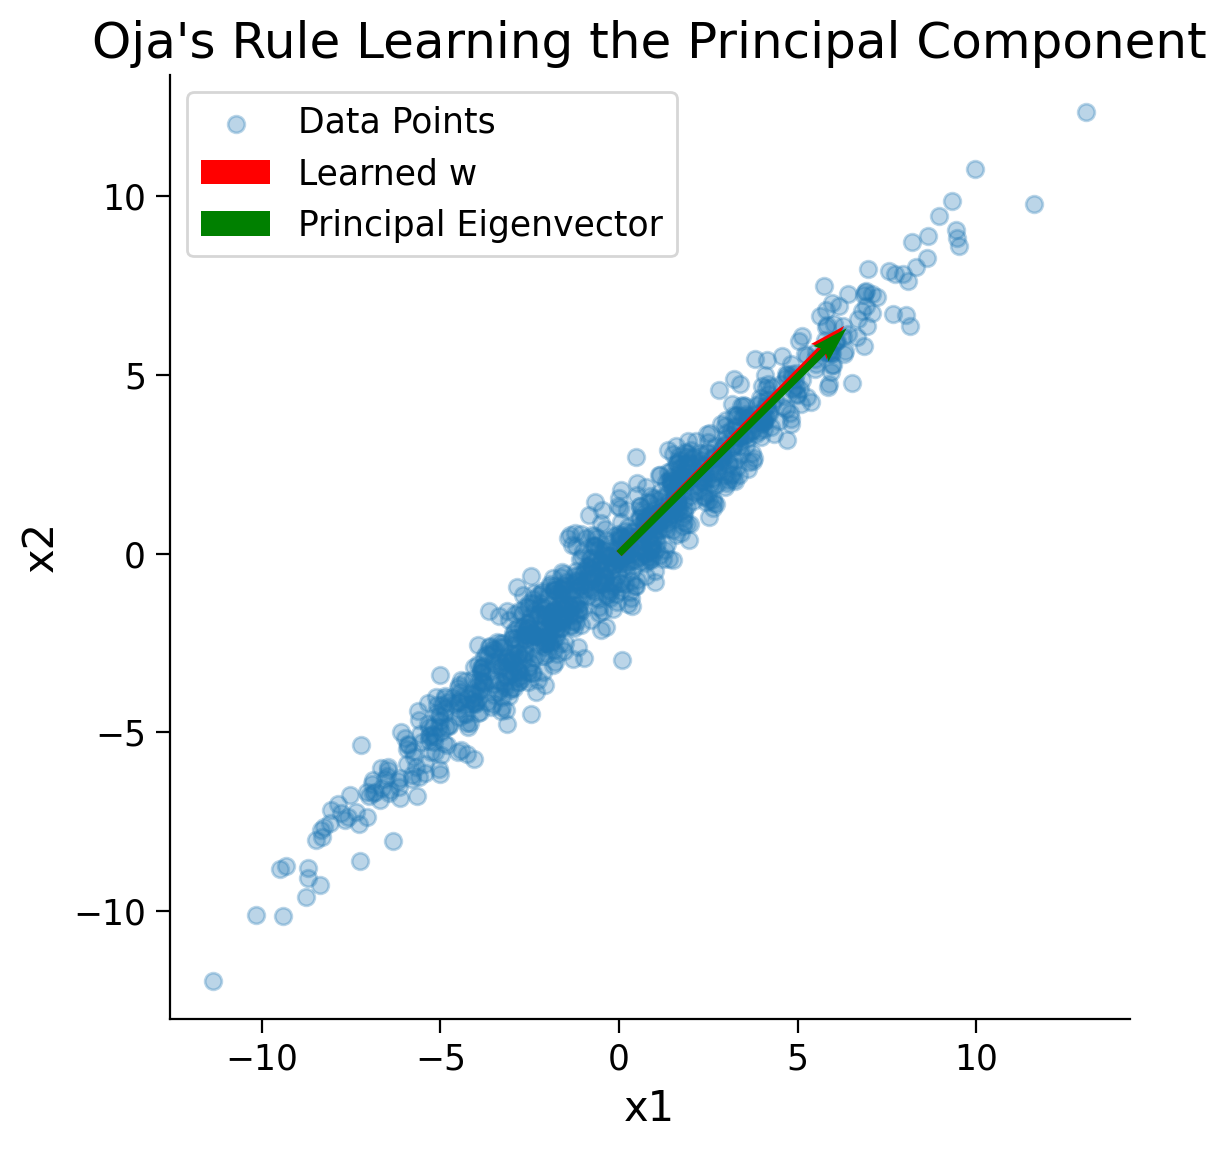

In [5]:

def generate_data(num_points=1000):
    """
    Generate 2D data points that have a clear principal component.
    We'll generate points primarily along a certain direction,
    with some noise.
    """
    # True principal eigenvector in 2D:
    # e.g. direction = (sqrt(2)/2, sqrt(2)/2) ~ 45° line.
    direction = np.array([1.0, 1.0])
    direction /= np.linalg.norm(direction)

    # Spread the data along 'direction' with some random noise
    # so that the leading principal component is along the 45° line.
    scale_factor = 5.0
    data = []
    for _ in range(num_points):
        # random coefficient for the main direction
        coeff = np.random.randn() * scale_factor
        # random noise orthogonal direction
        noise = np.random.randn(2) * 0.5

        point = coeff * direction + noise
        data.append(point)

    return np.array(data)


# 1) Generate 2D data
data = generate_data(num_points=1000)

# 2) Apply Oja's rule to find the principal component
learned_w = ojas_rule(data, eta=0.001, epochs=10)
print("Learned weight vector (direction):", learned_w)

# 3) Compare to the true principal eigenvector via covariance
cov_matrix = np.cov(data.T)
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)

# principal eigenvector is the eigenvector with the largest eigenvalue
idx_max = np.argmax(eigenvalues)
principal_eigenvector = eigenvectors[:, idx_max]

# Since direction can differ by sign only, we standardize sign
if np.dot(learned_w, principal_eigenvector) < 0:
    principal_eigenvector = -principal_eigenvector

print("Principal eigenvector from covariance:", principal_eigenvector)
print("Dot product (measure of similarity):", np.dot(learned_w, principal_eigenvector))

# 4) Plotting
plt.figure(figsize=(6, 6))
plt.scatter(data[:, 0], data[:, 1], alpha=0.3, label="Data Points")

# Plot learned vector
origin = np.zeros(2)
plt.quiver(*origin, *learned_w, color='r', scale=3, label='Learned w')
# Plot principal eigenvector
plt.quiver(*origin, *principal_eigenvector, color='g', scale=3, label='Principal Eigenvector')

plt.title("Oja's Rule Learning the Principal Component")
plt.xlabel("x1")
plt.ylabel("x2")
plt.axis('equal')
plt.legend()
plt.show()

### Sanger's rule: extracting all principal components

**Sanger's Rule Update Formula**

For a dataset with $ d $ input neurons and $ m $ output neurons (where $ m \leq d $), the weight update for output neuron $ i $ is:

$$
\mathbf{w}_i(n+1) = \mathbf{w}_i(n) + \eta y_i \left( \mathbf{x} - \sum_{j=1}^{i} y_j \mathbf{w}_j \right)
$$

where:
- $ \mathbf{w_i} $ is the weight vector for the $ i $-th neuron.
- $ \mathbf{x} $ is the input data vector.
- $ y_i = \mathbf{w_i}^T \mathbf{x} $ is the output neuron activity.
- $ -\sum_{j=1}^{i} y_j \mathbf{w_j} $ removes contributions from previous principal components.
- $ \eta $ is the learning rate.

**Step-by-Step Mechanism of Sanger's Rule**

**Step 1: Initialization**
- Start with **random** weight vectors $ w_1, w_2, ..., w_m $.
- Normalize them to ensure stability.

**Step 2: Learning Iterations**
For each input vector $ \mathbf{x} $, update the weights using:
1. Compute neuron outputs: $ y_i = \mathbf{w_i}^T \mathbf{x} $
2. Apply **Sanger's weight update**:
   - Each neuron updates its weights to maximize variance.
   - The **contribution from previous neurons** (previous principal components) is subtracted to ensure **orthogonality**. The update term $ -\sum_{j=1}^{i} y_j \mathbf{w}_j $ **removes the contribution of previous components**. This ensures that each weight vector remains **orthogonal** to previously learned components.

**Step 3: Convergence**
- The first output neuron's weights converge to the **first principal component (PC1)**.
- The second output neuron's weights converge to the **second principal component (PC2)**.
- This process continues, ensuring all extracted components are **mutually orthogonal**.


# Coding Exercise #2 (Line 32)

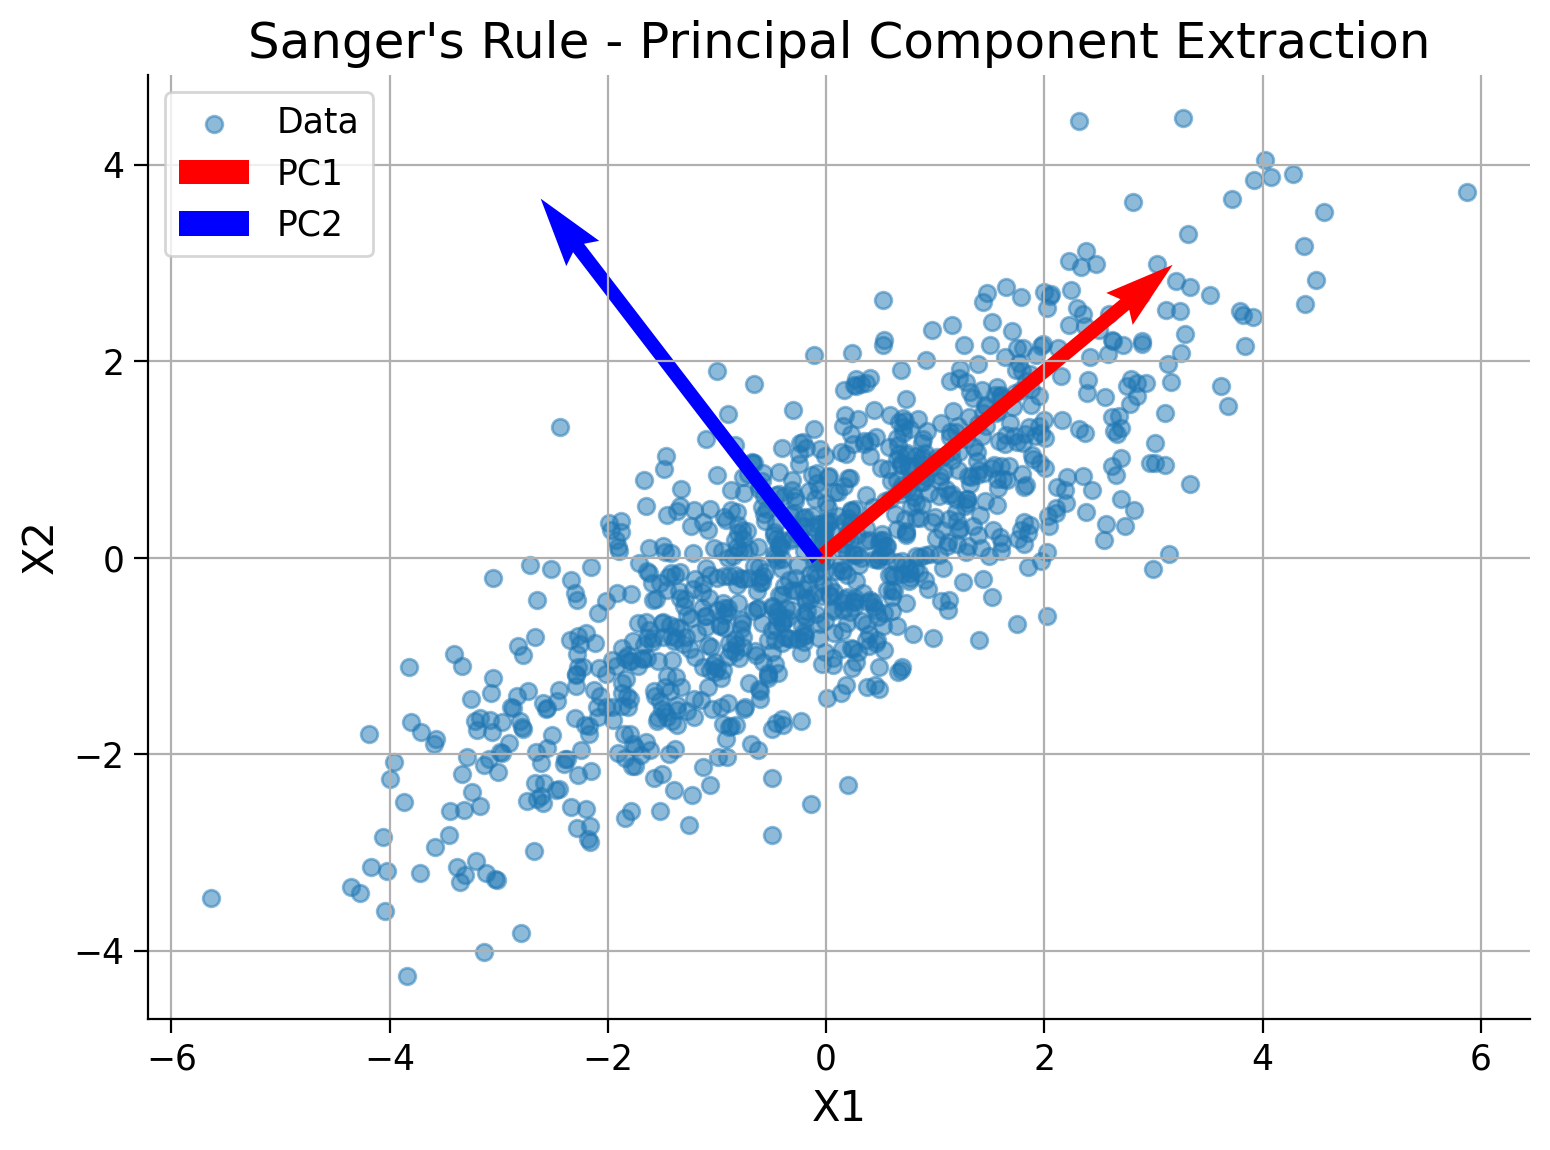

In [34]:

# Generate synthetic 2D data
np.random.seed(42)
n_samples = 1000

# Create correlated 2D data
mean = [0, 0]
cov = [[3, 2], [2, 2]]  # Covariance matrix
data = np.random.multivariate_normal(mean, cov, n_samples)

# Initialize weights randomly
n_features = 2  # 2D data
n_components = 2  # Extract 2 principal components
weights = np.random.rand(n_components, n_features)

# Learning rate
eta = 0.005
n_iterations = 100



#############################################################################
# Students: Fill in missing code (...) and comment or remove the next line
# raise NotImplementedError("Coding Exercise #2")
#############################################################################

# Sanger's rule training
for _ in range(n_iterations):
    for x in data:
        y = np.dot(weights, x)  # Compute neuron outputs
        for i in range(n_components):
            update = eta * y[i] * (x - np.dot(y[:i+1], weights[:i+1]))
            weights[i] += update






# Extract final principal components
pc1, pc2 = weights

# Plot data and extracted principal components
plt.figure(figsize=(8, 6))
plt.scatter(data[:, 0], data[:, 1], alpha=0.5, label='Data')

# Plot principal components
origin = np.mean(data, axis=0)
plt.quiver(*origin, *pc1, color='r', scale=3, width=0.01, label='PC1')
plt.quiver(*origin, *pc2, color='b', scale=3, width=0.01, label='PC2')

plt.xlabel('X1')
plt.ylabel('X2')
plt.legend()
plt.title("Sanger's Rule - Principal Component Extraction")
plt.grid()
plt.show()


# Question 1

What do you observe in the plots shown above?

PC1 has correctly captured the direction of maximum variance.

PC2 is capturing the residual variance — the smaller spread orthogonal to the main axis.

PC1 is approximately orthogonal to PC2.

Sanger’s rule is basically an online, neural-network way of performing eigenvector extraction. Extracts the principal axes of the covariance matrix.

A neural network discovering the eigenstructure of the covariance matrix through local Hebbian updates.

No matrix decomposition.
No SVD.
Just iterative adaptation.

It’s linear algebra emerging from dynamics.

# Backpropagation and Gradient Descent for Supervised Learning

Though Hebbian Learning and Competitive Learning can be used to perform unsupervised learning, they are usually not suitable for supervised learning. Backpropogation and Gradient Descent are typically used to train artificial neural networks with supervised learning.

The goal of most supervised learning algorithms is minimizing the loss function. The gradient descent algorithm, along with its variations such as stochastic gradient descent, is one of the most powerful and popular optimization methods used for minimizing the loss function in deep learning.

Before introducing the gradient descent algorithm, let's review a very important property of gradients. The gradient of a function always points in the direction of the steepest ascent. The following exercise will help clarify this.

### Analytical Exercise: Gradient vector  

Given the following function:

\begin{equation}
z = h(x, y) = \sin(x^2 + y^2)
\end{equation}

find the gradient vector:

\begin{equation}
  \begin{bmatrix}
  \dfrac{\partial z}{\partial x} \\ \\ \dfrac{\partial z}{\partial y}
  \end{bmatrix}
\end{equation}


*Hint: Use the chain rule!*

**Chain rule**: For a composite function $F(x) = g(h(x)) \equiv (g \circ h)(x)$:

\begin{equation}
F'(x) = g'(h(x)) \cdot h'(x)
\end{equation}

or differently denoted:

\begin{equation}
\frac{dF}{dx} = \frac{dg}{dh} ~ \frac{dh}{dx}
\end{equation}

<details>
<summary> <font color='green'>Click here for the solution </font></summary>

We can rewrite the function as a composite function:

\begin{equation}
z = f\left( g(x,y) \right), ~~ f(u) = \sin(u), ~~ g(x, y) = x^2 + y^2
\end{equation}

Using the [chain rule](https://en.wikipedia.org/wiki/Chain_rule):

\begin{align}
\dfrac{\partial z}{\partial x} &= \dfrac{\partial f}{\partial g} \dfrac{\partial g}{\partial x} = \cos(g(x,y)) ~ (2x) = \cos(x^2 + y^2) \cdot 2x \\ \\
\dfrac{\partial z}{\partial y} &= \dfrac{\partial f}{\partial g} \dfrac{\partial g}{\partial y} = \cos(g(x,y)) ~ (2y) = \cos(x^2 + y^2) \cdot 2y
\end{align}

## Gradient Descent Algorithm

Let $f(\mathbf{w}): \mathbb{R}^d \rightarrow \mathbb{R}$ be a differentiable function. Gradient Descent is an iterative algorithm for minimizing the function $f$, starting with an initial value for variables $\mathbf{w}$, taking steps of size $\eta$ (learning rate) in the direction of the negative gradient at the current point to update the variables $\mathbf{w}$.

\begin{equation}
\mathbf{w}^{(t+1)} = \mathbf{w}^{(t)} - \eta \nabla f \left( \mathbf{w}^{(t)} \right)
\end{equation}

where $\eta > 0$ and $\nabla f (\mathbf{w})= \left( \frac{\partial f(\mathbf{w})}{\partial w_1}, ..., \frac{\partial f(\mathbf{w})}{\partial w_d} \right)$. Since negative gradients always point locally in the direction of steepest descent, the algorithm makes small steps at each point **towards** the minimum.

<br/>

**Vanilla Algorithm**

---
> **Inputs:** initial guess $\mathbf{w}^{(0)}$, step size $\eta > 0$, number of steps $T$.

> **For** $t = 0, 1, 2, \dots , T-1$ **do** \
$\qquad$ $\mathbf{w}^{(t+1)} = \mathbf{w}^{(t)} - \eta \nabla f \left( \mathbf{w}^{(t)} \right)$\
**end**

> **Return:** $\mathbf{w}^{(t+1)}$

---

<br/>

Hence, all we need is to calculate the gradient of the loss function with respect to the learnable parameters (i.e., weights):

\begin{equation}
\dfrac{\partial Loss}{\partial \mathbf{w}} = \left[ \dfrac{\partial Loss}{\partial w_1}, \dfrac{\partial Loss}{\partial w_2} , \dots, \dfrac{\partial Loss}{\partial w_d} \right]^{\top}
\end{equation}

## Computational Graphs and Backpropagation

Let's look at a function:

\begin{equation}
f(x, y, z) = \tanh \left(\ln \left[1 + z \frac{2x}{sin(y)} \right] \right)
\end{equation}

It is an example of how overwhelming the derivation of gradients can get, as the number of variables and nested functions increases. This function is still extraordinarily simple compared to the loss functions of modern neural networks. So how can we (as well as PyTorch and similar frameworks) approach such beasts?

**computational graph**

We can build a so-called computational graph (shown below) to break the original function into smaller and more approachable expressions.

<center><img src="https://raw.githubusercontent.com/NeuromatchAcademy/course-content-dl/main/tutorials/W1D2_LinearDeepLearning/static/comput_graph.png" alt="Computation Graph" width="700"/></center>

Starting from $x$, $y$, and $z$ and following the arrows and expressions, you would see that our graph returns the same function as $f$. It does so by calculating intermediate variables $a,b,c,d,$ and $e$. This is called the **forward pass**.

Now, let’s start from $f$, and work our way against the arrows while calculating the gradient of each expression as we go. This is called the **backward pass**, from which the **backpropagation of errors** algorithm gets its name.

<center><img src="https://raw.githubusercontent.com/NeuromatchAcademy/course-content-dl/main/tutorials/W1D2_LinearDeepLearning/static/comput_graph_full.png" alt="Computation Graph full" width="1200"/></center>

By breaking the computation into simple operations on intermediate variables, we can use the chain rule to calculate any gradient:

\begin{equation}
\dfrac{\partial f}{\partial x} = \dfrac{\partial f}{\partial e}~\dfrac{\partial e}{\partial d}~\dfrac{\partial d}{\partial c}~\dfrac{\partial c}{\partial a}~\dfrac{\partial a}{\partial x} = \left( 1-\tanh^2(e) \right) \cdot \frac{1}{d+1}\cdot z \cdot \frac{1}{b} \cdot 2
\end{equation}

Conveniently, the values for $e$, $b$, and $d$ are available to us from when we did the forward pass through the graph. That is, the partial derivatives have simple expressions in terms of the intermediate variables $a,b,c,d,e$ that we calculated and stored during the forward pass.

# Question 2

Analytical Exercise: Chain Rule using computational graph

For the function above, calculate the $\dfrac{\partial f}{\partial y}$ using the computational graph and chain rule.



We define intermediate variables:

$$
u = \sin y
$$

$$
v = \frac{2x}{u}
$$

$$
w = z v
$$

$$
a = 1 + w
$$

$$
b = \ln a
$$

$$
f = \tanh b
$$

---

Using the chain rule:

$$
\frac{\partial f}{\partial y}
=
\frac{\partial f}{\partial b}
\frac{\partial b}{\partial a}
\frac{\partial a}{\partial w}
\frac{\partial w}{\partial v}
\frac{\partial v}{\partial u}
\frac{\partial u}{\partial y}
$$

Now compute each partial derivative:

$$
\frac{\partial f}{\partial b}
=
1 - \tanh^2(b)
$$

$$
\frac{\partial b}{\partial a}
=
\frac{1}{a}
$$

$$
\frac{\partial a}{\partial w}
=
1
$$

$$
\frac{\partial w}{\partial v}
=
z
$$

$$
\frac{\partial v}{\partial u}
=
-\frac{2x}{u^2}
$$

$$
\frac{\partial u}{\partial y}
=
\cos y
$$

---

Multiplying everything:

$$
\frac{\partial f}{\partial y}
=
\left(1-\tanh^2(b)\right)
\cdot
\frac{1}{a}
\cdot
z
\cdot
\left(-\frac{2x}{u^2}\right)
\cdot
\cos y
$$

---

Substituting back:

$$
\frac{\partial f}{\partial y}
=
\left(1-\tanh^2\!\left(\ln\!\left[1+z\frac{2x}{\sin y}\right]\right)\right)
\cdot
\frac{-2xz\cos y}
{\sin^2 y\left(1+z\frac{2x}{\sin y}\right)}
$$

# Question 3

Do you think backpropagation is biologically plausible? Why or why not?

Standard backpropagation is not biologically plausible because it requires symmetric forward and backward weights, precise global error signals, and exact gradient computations, none of which are clearly observed in real neural circuits. Biological neurons mostly rely on local learning rules and modulatory signals rather than layer-by-layer error propagation. However, the brain does appear to use error-like signals (e.g., dopamine reward prediction errors) that resemble gradient-based learning in spirit. So while exact backprop is unlikely in biology, the general idea of error-driven adaptation may still be implemented in a different, more biologically realistic way.

## PyTorch's Neural Net module (`nn.Module`)

PyTorch provides us with ready-to-use neural network building blocks, such as layers (e.g., linear, recurrent, etc.), different activation and loss functions, and much more, packed in the [`torch.nn`](https://pytorch.org/docs/stable/nn.html) module. If we build a neural network using `torch.nn` layers, the weights and biases are already in `requires_grad` mode and will be registered as model parameters.

For training, we need three things:

* **Model parameters:** Model parameters refer to all the learnable parameters of the model, which are accessible by calling `.parameters()` on the model. Please note that NOT all the `requires_grad` tensors are seen as model parameters. To create a custom model parameter, we can use [`nn.Parameter`](https://pytorch.org/docs/stable/generated/torch.nn.parameter.Parameter.html) (*A kind of Tensor that is to be considered a module parameter*).

* **Loss function:** The loss that we are going to be optimizing, which is often combined with regularization terms (coming up in few days).

* **Optimizer:** PyTorch provides us with many optimization methods (different versions of gradient descent). Optimizer holds the current state of the model and by calling the `step()` method, will update the parameters based on the computed gradients.

You will learn more details about choosing the right model architecture, loss function, and optimizer later in the course.

### Training loop in PyTorch

We use a regression problem to study the training loop in PyTorch.

The task is to train a wide nonlinear (using $\tanh$ activation function) neural net for a simple $\sin$ regression task. Wide neural networks are thought to be really good at generalization.

Random seed 2025 has been set.


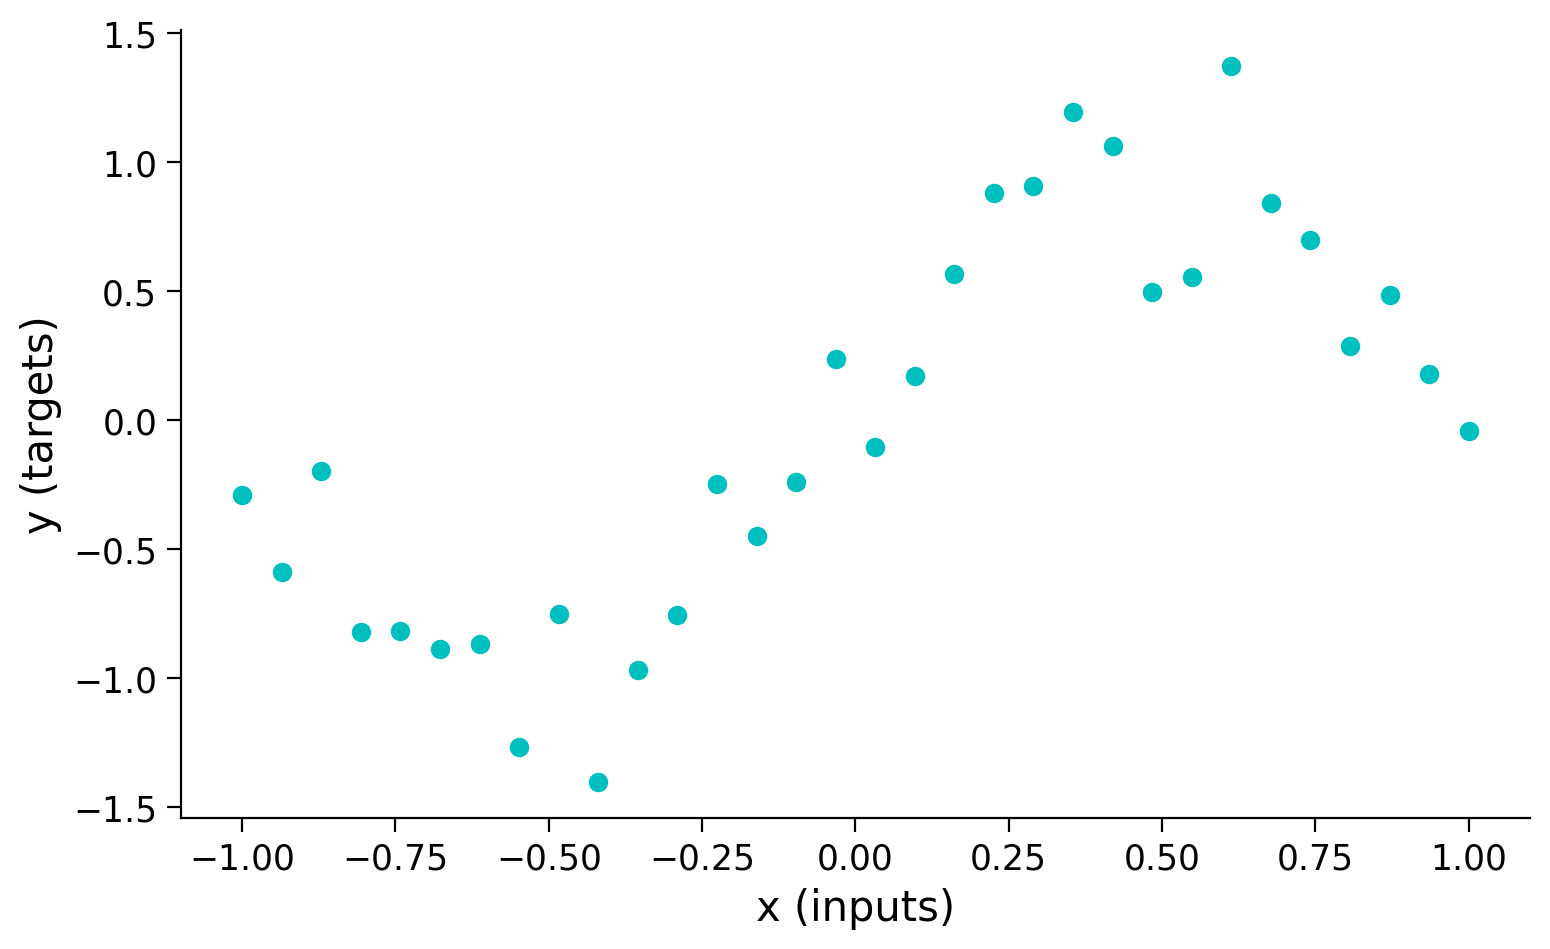

In [35]:
# @markdown #### Generate the sample dataset
set_seed(seed=SEED)
n_samples = 32
inputs = torch.linspace(-1.0, 1.0, n_samples).reshape(n_samples, 1)
noise = torch.randn(n_samples, 1) / 4
targets = torch.sin(pi * inputs) + noise
plt.figure(figsize=(8, 5))
plt.scatter(inputs, targets, c='c')
plt.xlabel('x (inputs)')
plt.ylabel('y (targets)')
plt.show()

Let's define a very wide (512 neurons) neural net with one hidden layer and `nn.Tanh()` activation function.

# Coding Exercise #3 (Lines 30 and 32)

In [36]:
class WideNet(nn.Module):
  """
   A Wide neural network with a single hidden layer

   Structure is as follows:
   nn.Sequential(
        nn.Linear(1, n_cells) + nn.Tanh(), # Fully connected layer with tanh activation
        nn.Linear(n_cells, 1) # Final fully connected layer
    )
  """

#############################################################################
# Students: Fill in missing code (...) and comment or remove the next line
# raise NotImplementedError("Coding Exercise #3")
#############################################################################

  def __init__(self):
    """
    Initializing the parameters of WideNet

    Args:
      None

    Returns:
      Nothing
    """
    n_cells = 512
    super().__init__()
    self.layers = nn.Sequential(
        nn.Linear(1, n_cells),
        nn.Tanh(),
        nn.Linear(n_cells, 1),
    )

  def forward(self, x):
    """
    Forward pass of WideNet

    Args:
      x: torch.Tensor
        2D tensor of features

    Returns:
      Torch tensor of model predictions
    """
    return self.layers(x)

We can now create an instance of our neural net and print its parameters.

In [37]:
# Creating an instance
set_seed(seed=SEED)
wide_net = WideNet()
print(wide_net)

Random seed 2025 has been set.
WideNet(
  (layers): Sequential(
    (0): Linear(in_features=1, out_features=512, bias=True)
    (1): Tanh()
    (2): Linear(in_features=512, out_features=1, bias=True)
  )
)


In [38]:
# Create a mse loss function
loss_function = nn.MSELoss()

# Stochstic Gradient Descent optimizer (you will learn about momentum soon)
lr = 0.003  # Learning rate
sgd_optimizer = torch.optim.SGD(wide_net.parameters(), lr=lr, momentum=0.9)

The training process in PyTorch is interactive - you can perform training iterations as you wish and inspect the results after each iteration.

Let's perform one training iteration. You can run the cell multiple times and see how the parameters are being updated and the loss is reducing. This code block is the core of everything to come: please make sure you go line-by-line through all the commands and discuss their purpose with your pod.

In [39]:
# Reset all gradients to zero
sgd_optimizer.zero_grad()

# Forward pass (Compute the output of the model on the features (inputs))
prediction = wide_net(inputs)

# Compute the loss
loss = loss_function(prediction, targets)
print(f'Loss: {loss.item()}')

# Perform backpropagation to build the graph and compute the gradients
loss.backward()

# Optimizer takes a tiny step in the steepest direction (negative of gradient)
# and "updates" the weights and biases of the network
sgd_optimizer.step()

Loss: 0.847880482673645


# Coding Exercise #4 (Lines 35 and 37)

Random seed 2025 has been set.


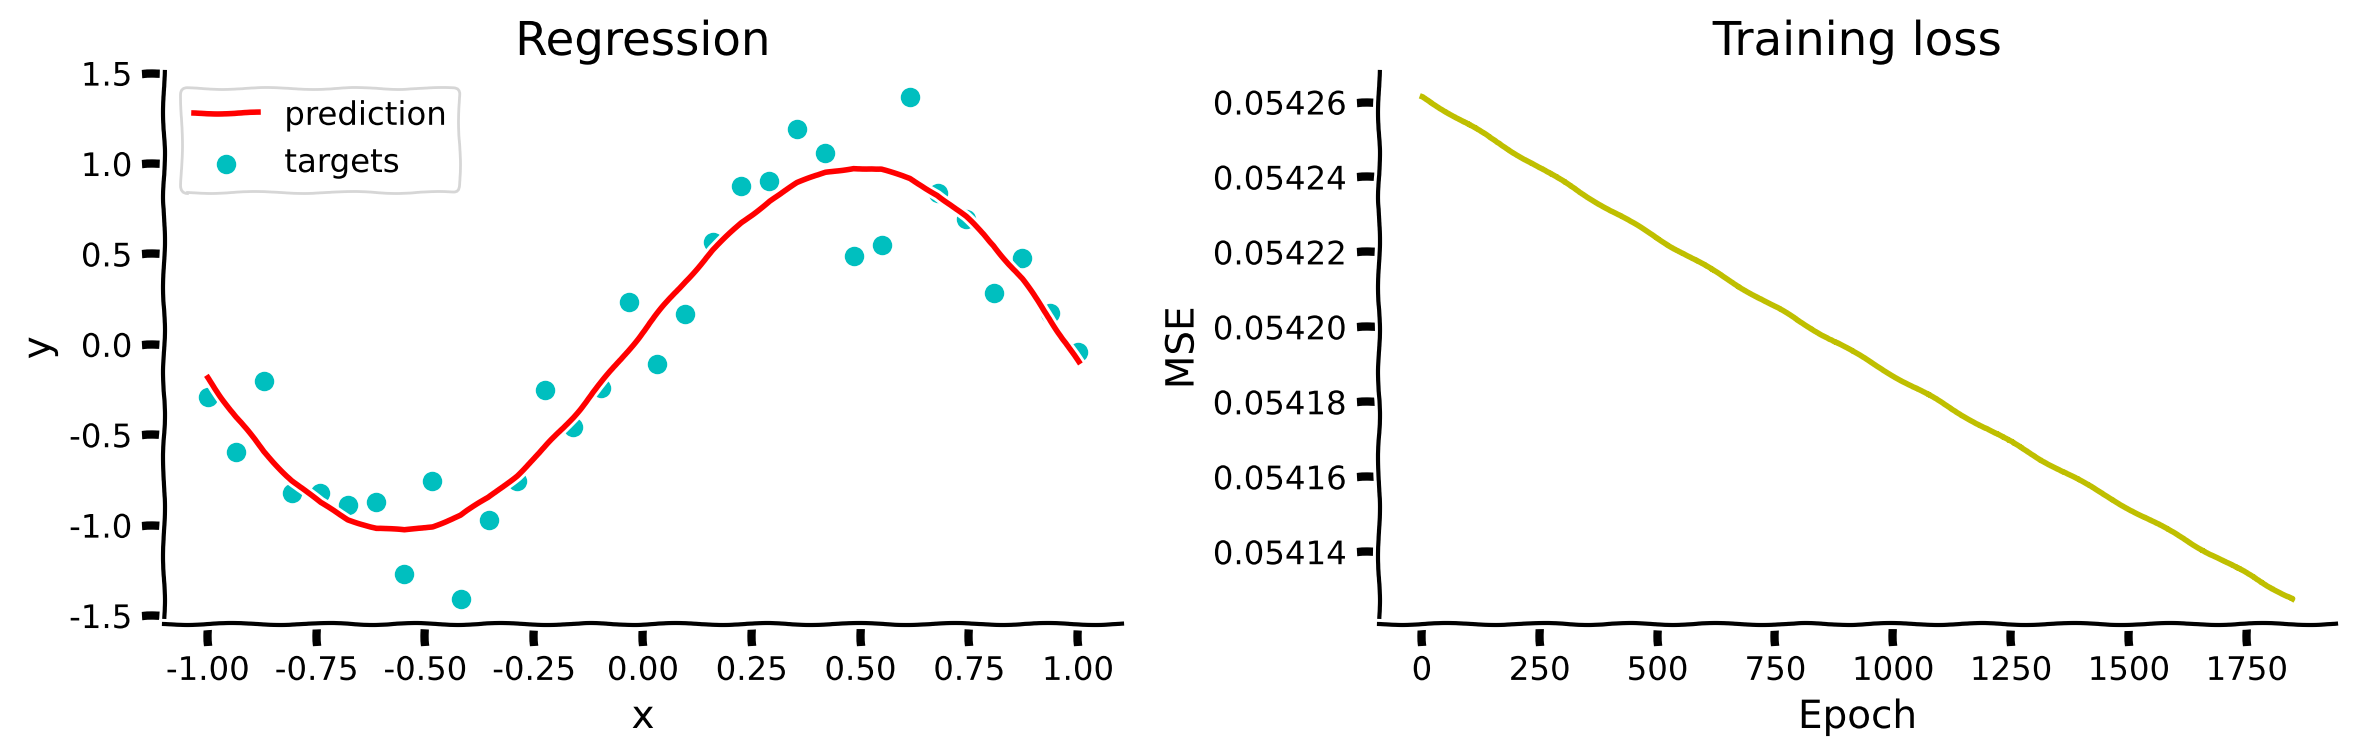

In [44]:

#############################################################################
# Students: Fill in missing code (...) and comment or remove the next line
# raise NotImplementedError("Coding Exercise #4")
#############################################################################

def train(features, labels, model, loss_fun, optimizer, n_epochs):
  """
  Training function

  Args:
    features: torch.Tensor
      Features (input) with shape torch.Size([n_samples, 1])
    labels: torch.Tensor
      Labels (targets) with shape torch.Size([n_samples, 1])

    model: torch nn.Module
      The neural network
    loss_fun: function
      Loss function that will take (predictions, labels) as inputs
    optimizer: function
      Optimizer
    n_epochs: int
      Number of training iterations

  Returns:
    loss_record: list
      Record (evolution) of training losses
  """
  loss_record = []  # Keeping recods of loss

  for i in range(n_epochs):
    optimizer.zero_grad()  # Set gradients to 0

    predictions = model(features)  # Compute model prediction (output)

    loss = loss_fun(predictions, labels)  # Compute the loss

    loss.backward()  # Compute gradients (backward pass)
    optimizer.step()  # Update parameters (optimizer takes a step)

    loss_record.append(loss.item())
  return loss_record



set_seed(seed=2025)
epochs = 1847 # Cauchy, Exercices d'analyse et de physique mathematique (1847)

## run
losses = train(inputs, targets, wide_net, loss_function, sgd_optimizer, epochs)
with plt.xkcd():
  ex3_plot(wide_net, inputs, targets, epochs, losses)
